In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def conservation_measures(t, reduction_amount, policy, action_name, capacity, t_depl, c1, c2):
    i = 0
    for action in action_name:
        if policy == action:
            rr = capacity[i]/100.0
            t_deploy = t_depl[i]
            break
        i = i + 1

    Ti = int(min(1200, t + t_deploy))
    Tf = int(min(1200, Ti + 60)) #from the curve, forget effect after 60 months
    uptake = [1 - (1/(1+np.exp((tt-(c1*12))/c2))) for tt in range(Tf - Ti)]
    reduction_amount[Ti:Tf] = [((rr-exist_red)*up + exist_red) for exist_red,up in zip(reduction_amount[Ti:Tf],uptake)]
    reduction_amount[Tf:] = rr*np.ones(len(reduction_amount[Tf:]))
    return reduction_amount

In [3]:
def conservation_measures_remove(t, reduction_amount, policy, Location, action_name, capacity, t_depl, c1, c2):
    remainder = 0
    t_deploy = 0
    final_rr = 0.0

    if policy == 'd1':
        remainder = 0
    elif policy == 'd2':
        if Location['D1'] == 1:
            remainder = 'd1'
        else:
            remainder = 0
    elif policy == 'd3':
        if Location['D2'] == 1:
            remainder = 'd2'
        elif Location['D1'] == 1:
            remainder = 'd1'
        else:
            remainder = 0
    

    i = 0
    term = 50*12 #if not continuing with a different level of curtailment, forget curtailment after 50 years
    for action in action_name:
        if policy == action:
            t_deploy = t_depl[i]
        if action == remainder:
            if capacity[i]/100.0 == 0.0:
                final_rr = 0.0
            else:
                final_rr = capacity[i]/100.0

        i = i + 1

    Ti = min(t + t_deploy, 1200)
    Tf = min(Ti + int(term), 1200)
    surv = [1/(1+np.exp((tt-(c1*12))/c2)) for tt in range(Tf - Ti)]
    array = []
    j = Ti
    k = 0
    exist_red = reduction_amount[Ti]
    while j < Tf:
        su = surv[k]
        array.append((((exist_red-final_rr)*su) + final_rr))
        j = j + 1
        k = k + 1
    reduction_amount[Ti:Tf] = array
    reduction_amount[Tf:] = final_rr*np.ones(len(reduction_amount[Tf:]))
    return reduction_amount

In [4]:
reduction_amount = np.zeros(1200)
Location = {'Desal': 0, 'WWTP': 0, 'L1':0, 'L2':0, 'L3':0, 'L4':0, 'L5':0, 'L6':0, 'L7':0, 'D1':0, 'D2':0, 'D3':0}
df_actions_table = pd.read_csv("data/actions_table.csv")
action_name = df_actions_table['action'].values
capacity = df_actions_table['capacity (af/month)'].values
om = df_actions_table['OPEX ($10^6/af/year)'].values
cx = df_actions_table['CAPEX($10^6)'].values
t_depl = df_actions_table['time to deployment (month)'].values
lifetime = df_actions_table['lifetime (year)'].values
action_type = [int(val) for val in df_actions_table['action_type'].values]

In [ ]:
perc_cap = 5

c1c = 2.5
c2c = c1c*1.6
c1d = 7.5
c2d = c1d*2.0

capacity[14] = 0 + 15*(perc_cap/100)
capacity[15] = 15 + (25-15)*(perc_cap/100)
capacity[16] = 25 + (50-25)*(perc_cap/100)

In [6]:
Location['D1'] = 1
reduction_amount = conservation_measures(100, reduction_amount, 'd1', action_name, capacity, t_depl, c1c, c2c)

Location['D2'] = 1
reduction_amount = conservation_measures(300, reduction_amount, 'd2', action_name, capacity, t_depl, c1c, c2c)

Location['D3'] = 1
reduction_amount = conservation_measures(500, reduction_amount, 'd3', action_name, capacity, t_depl, c1c, c2c)

Location['D3'] = 0
reduction_amount = conservation_measures_remove(600, reduction_amount, 'd3', Location, action_name, capacity, t_depl, c1d, c2d)

Location['D1'] = 0
reduction_amount = conservation_measures_remove(800, reduction_amount, 'd1', Location, action_name, capacity, t_depl, c1d, c2d)

Location['D1'] = 0
reduction_amount = conservation_measures_remove(1000, reduction_amount, 'd1', Location, action_name, capacity, t_depl, c1d, c2d)

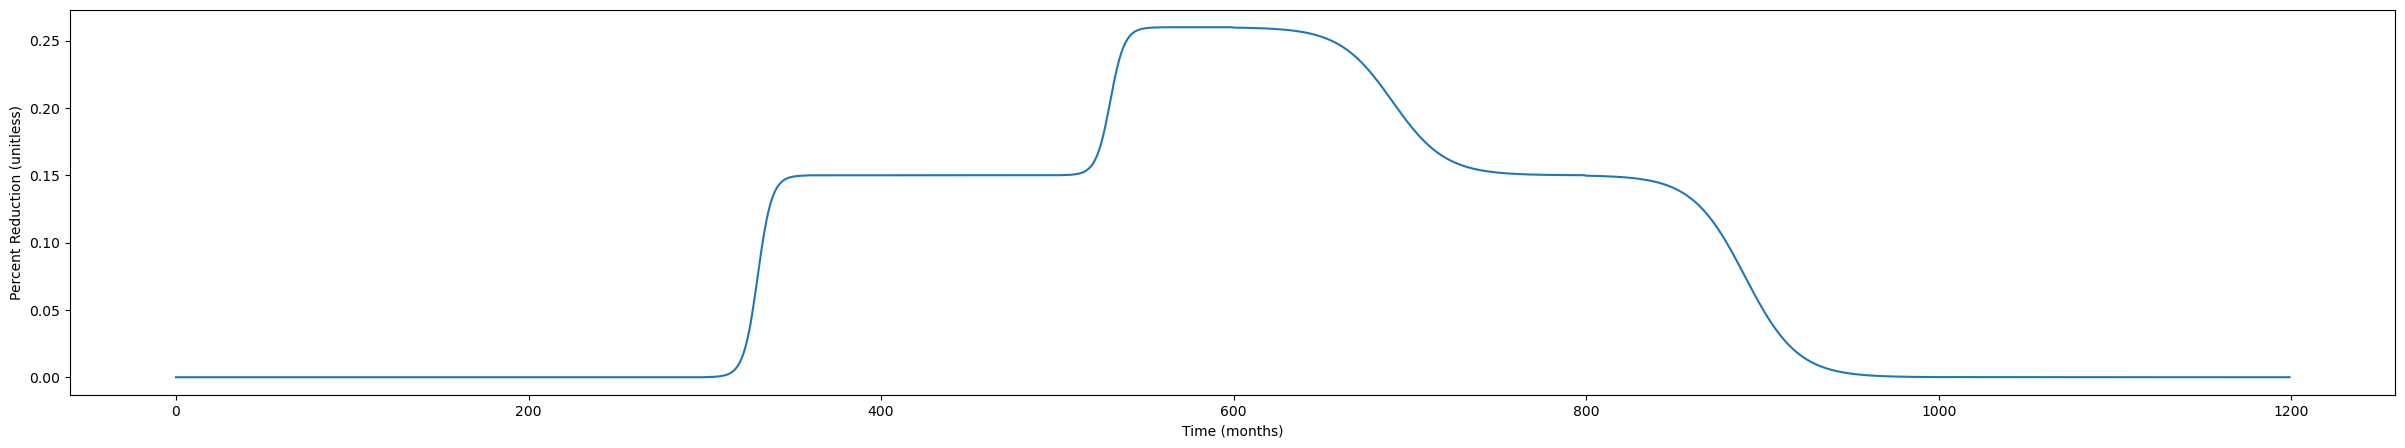

In [7]:
plt.figure(figsize = (30,5))
plt.plot(reduction_amount);
plt.xlabel("Time (months)");
plt.ylabel("Percent Reduction (unitless)");

In [8]:
demand = np.loadtxt('data/SB_water_demand.txt')

demand_f = []
for j in range(1200):
    demand_f.append(demand[j%12]*(1 - reduction_amount[j]))

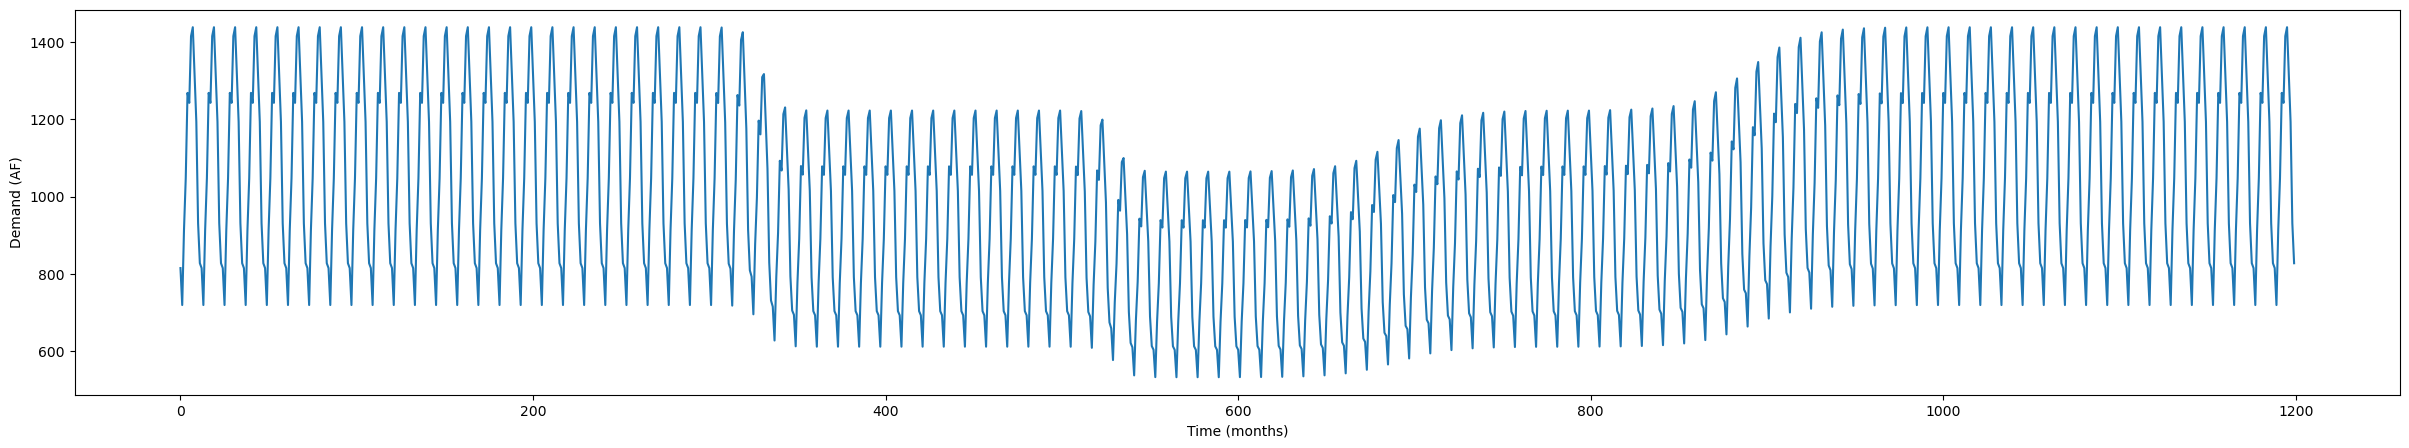

In [9]:
plt.figure(figsize = (30,5))
plt.plot(demand_f);
plt.xlabel("Time (months)");
plt.ylabel("Demand (AF)");